# 01 Power Curve Fitting

这个 notebook 展示风机级 SCADA 样例数据如何清洗、预处理并构建经验功率曲线。公开版只使用合成样例数据，字段和处理流程对应真实工程，但不包含真实风机原始数据。

## 1. Data Description

`sample_turbine_scada.csv` 包含 `timestamp`、`turbine_id`、`wind_speed`、`power_kw`、`status`。真实项目中这些字段通常来自 15 分钟 SCADA 报表；公开样例保留字段结构，用于说明功率曲线拟合过程。

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wind_power_baselines.preprocessing import clean_scada
from wind_power_baselines.power_curve import build_power_curve

sns.set_theme(style='whitegrid')
scada = pd.read_csv(PROJECT_ROOT / 'data_sample' / 'sample_turbine_scada.csv')
scada.head()

,timestamp,turbine_id,wind_speed,power_kw,status
0,2025-01-01 00:00:00,T01,7.045,261.693,normal
1,2025-01-01 00:15:00,T01,5.538,77.813,normal
2,2025-01-01 00:30:00,T01,3.643,22.574,normal
3,2025-01-01 00:45:00,T01,5.350,86.986,normal
4,2025-01-01 01:00:00,T01,6.447,216.009,normal


## 2. Data Cleaning

清洗步骤包括：解析时间、删除重复时间戳、保留 `normal` 状态、剔除负风速/超物理风速、剔除负功率。这样做的原因是停机、限功率和采集异常会把经验功率曲线拉偏。

In [2]:
cleaned = clean_scada(scada)
print({'raw_rows': len(scada), 'cleaned_rows': len(cleaned), 'removed_rows': len(scada) - len(cleaned)})
cleaned.head()

{'raw_rows': 579, 'cleaned_rows': 558, 'removed_rows': 21}


,timestamp,turbine_id,wind_speed,power_kw,status,month,season
0,2025-01-01 00:00:00,T01,7.045,261.693,normal,2025-01,winter
1,2025-01-01 00:15:00,T01,5.538,77.813,normal,2025-01,winter
2,2025-01-01 00:30:00,T01,3.643,22.574,normal,2025-01,winter
3,2025-01-01 00:45:00,T01,5.350,86.986,normal,2025-01,winter
4,2025-01-01 01:00:00,T01,6.447,216.009,normal,2025-01,winter


## 3. EDA Before Fitting

先看风速和功率的散点分布，再看不同风机的样本覆盖。真实项目中如果某台风机某个风速段样本很少，曲线会不稳定，需要在评估里标注。

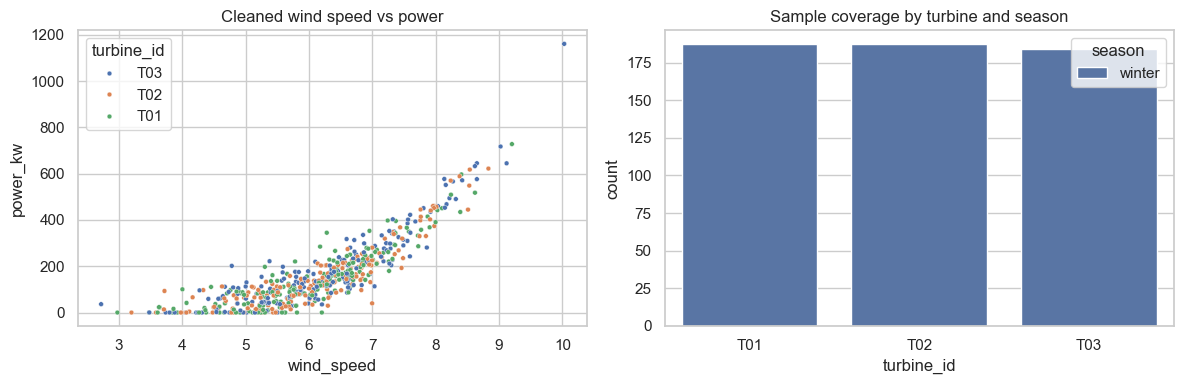

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=cleaned.sample(min(1000, len(cleaned)), random_state=7), x='wind_speed', y='power_kw', hue='turbine_id', s=12, ax=axes[0])
sns.countplot(data=cleaned, x='turbine_id', hue='season', ax=axes[1])
axes[0].set_title('Cleaned wind speed vs power')
axes[1].set_title('Sample coverage by turbine and season')
fig.tight_layout()

## 4. Preprocessing And Curve Construction

公开版采用风速分箱后的中位数功率作为经验功率曲线。中位数比均值更稳健，因为散点里常有停机、限功率、切出和传感器异常。

In [4]:
curve = build_power_curve(cleaned, 0.5, 12)
curve.to_csv(PROJECT_ROOT / 'data_sample' / 'sample_power_curve.csv', index=False)
curve.head()

,turbine_id,season,wind_speed_bin,power_kw,sample_count
0,T01,winter,4.5,30.304,20
1,T01,winter,5.0,39.638,31
2,T01,winter,5.5,80.716,28
3,T01,winter,6.0,157.488,33
4,T01,winter,6.5,180.896,31


## 5. Fitting Result

下图展示每台风机、每个季节的经验功率曲线。第二个点预测 notebook 会直接读取这个曲线表，把预报风速映射为电量。

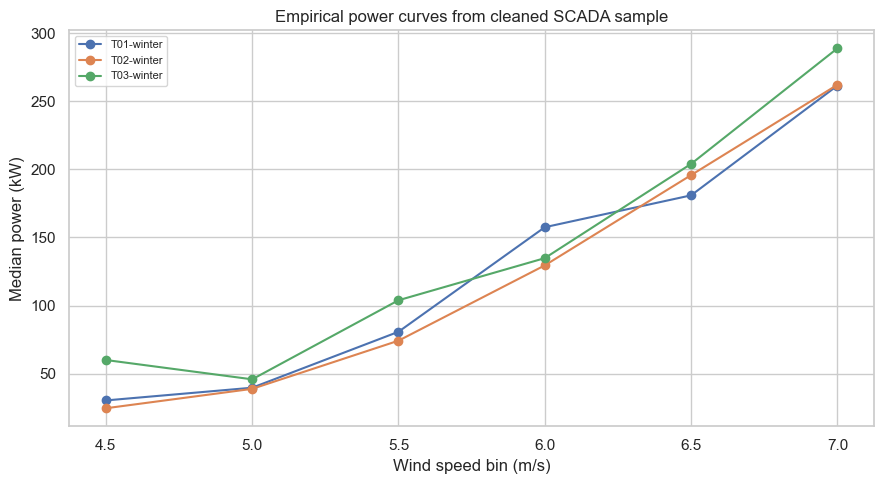

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for (turbine_id, season), group in curve.groupby(['turbine_id', 'season']):
    ax.plot(group['wind_speed_bin'], group['power_kw'], marker='o', label=f'{turbine_id}-{season}')
ax.set_xlabel('Wind speed bin (m/s)')
ax.set_ylabel('Median power (kW)')
ax.set_title('Empirical power curves from cleaned SCADA sample')
ax.legend(fontsize=8)
fig.tight_layout()

## 6. Actual Public Figures

下面几张图由本地真实中间结果渲染后以 PNG 形式放入仓库。原始 SCADA 和原始风塔/测风文件不上传，但图可以正常展示真实分布和拟合形态。

![Observed wind speed distribution](../figures/power_curve/actual_wind_distribution_by_turbine.png)

这张图先看每台风机的观测风速分布。它用于判断不同风机是否处在相近风况下，也能发现某台风机是否存在明显偏低、偏高或缺测较多的问题。

![Daily observed wind speed vs normalized energy](../figures/power_curve/actual_daily_wind_energy_scatter.png)

这张图把日均观测风速和日真值电量指数放在一起。风速越高，电量指数整体越高，说明功率曲线和月度预测都必须先把风速侧处理稳，否则后面的电量预测会被系统性带偏。

![Actual fitted power curves by turbine](../figures/power_curve/actual_power_curve_all_turbines.png)

这张图展示真实拟合出来的逐机功率曲线。不同风机曲线并不完全重合，所以公开说明里保留逐机拆分，而不是只给一条场站平均曲线。

![Seasonal fitted power curves](../figures/power_curve/actual_power_curve_seasonal.png)

这张图展示分季节曲线和风速 bin 覆盖。季节拆分的意义是把空气密度、运行策略和季节性风况差异吸收进功率曲线，但样本覆盖不足的高风速段需要谨慎解释。

## 7. Output

输出文件是 `data_sample/sample_power_curve.csv`，字段为 `turbine_id`、`season`、`wind_speed_bin`、`power_kw`、`sample_count`。它是后续 Baseline 2/3/4 和 AK-D 的风速到功率映射底座。